# Sales and Delivery Analysis

## Data Loading and Grain Collapse
Similar to the customer analysis, we collapse the `master_table.csv` to the order grain for revenue and delivery analysis, to avoid counting an order's revenue multiple times. We will use the original item-grain data specifically for category-level analysis.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('../data/processed/master_table.csv')
df_orders = df.drop_duplicates(subset=['order_id']).copy()

# Convert date columns
date_cols = ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in date_cols:
    df_orders[col] = pd.to_datetime(df_orders[col])
    if col in df.columns:
        df[col] = pd.to_datetime(df[col])

## Monthly Revenue Trend

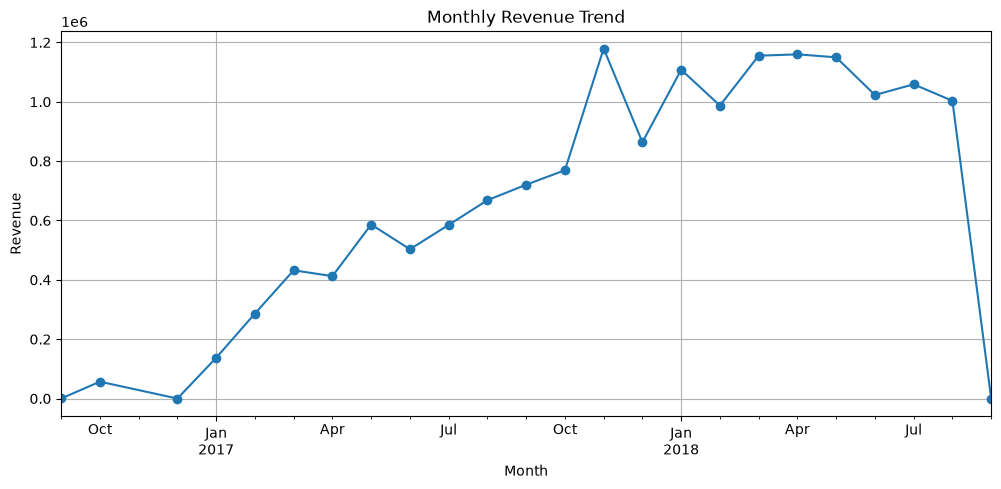

In [2]:
df_orders['purchase_month'] = df_orders['order_purchase_timestamp'].dt.to_period('M')
monthly_revenue = df_orders.groupby('purchase_month')['payment_value'].sum()

plt.figure(figsize=(12, 5))
monthly_revenue.plot(kind='line', marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid(True)
plt.show()

## Top Customer States by Revenue

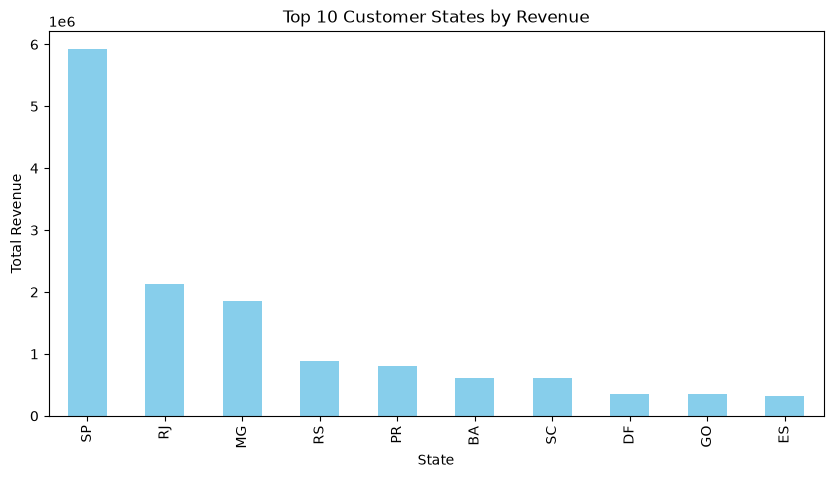

In [3]:
state_revenue = df_orders.groupby('customer_state')['payment_value'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
state_revenue.plot(kind='bar', color='skyblue')
plt.title('Top 10 Customer States by Revenue')
plt.xlabel('State')
plt.ylabel('Total Revenue')
plt.show()

## Top Product Categories by Revenue and Item Count
We compute this from the un-collapsed master table, as categories apply at the item level.

In [4]:
# Using 'df' (item grain)
category_stats = df.groupby('product_category_name_english').agg(
    item_count=('order_item_id', 'count'),
    total_revenue=('price', 'sum') # using price for item-level revenue
)

print('--- Top 10 Categories by Item Count ---')
print(category_stats.sort_values('item_count', ascending=False).head(10)[['item_count']])

print('\n--- Top 10 Categories by Revenue ---')
print(category_stats.sort_values('total_revenue', ascending=False).head(10)[['total_revenue']])

--- Top 10 Categories by Item Count ---
                               item_count
product_category_name_english            
bed_bath_table                      11115
health_beauty                        9670
sports_leisure                       8641
furniture_decor                      8334
computers_accessories                7827
housewares                           6964
watches_gifts                        5991
telephony                            4545
garden_tools                         4347
auto                                 4235

--- Top 10 Categories by Revenue ---
                               total_revenue
product_category_name_english               
health_beauty                     1258681.34
watches_gifts                     1205005.68
bed_bath_table                    1036988.68
sports_leisure                     988048.97
computers_accessories              911954.32
furniture_decor                    729762.49
cool_stuff                         635290.85
housewares   

## Delivery Performance
We analyze delivery delays using only orders with a genuinely non-null delivery date.

In [5]:
missing_delivery = df_orders['order_delivered_customer_date'].isnull().sum()
total_orders = len(df_orders)
print(f"Excluded {missing_delivery} orders ({(missing_delivery/total_orders)*100:.2f}%) due to missing delivery dates.")

delivered = df_orders.dropna(subset=['order_delivered_customer_date']).copy()
delivered['actual_delivery_days'] = (delivered['order_delivered_customer_date'] - delivered['order_purchase_timestamp']).dt.days
delivered['estimated_delivery_days'] = (delivered['order_estimated_delivery_date'] - delivered['order_purchase_timestamp']).dt.days
delivered['delivery_delay_days'] = (delivered['order_delivered_customer_date'] - delivered['order_estimated_delivery_date']).dt.days
delivered['is_late'] = delivered['delivery_delay_days'] > 0

print('\n--- Overall Delivery Performance ---')
print(f"Avg Actual Delivery Days: {delivered['actual_delivery_days'].mean():.2f}")
print(f"Avg Estimated Delivery Days: {delivered['estimated_delivery_days'].mean():.2f}")
print(f"Overall Late Delivery Rate: {delivered['is_late'].mean()*100:.2f}%")

print('\n--- Late Delivery Rate by Customer State ---')
late_by_state = delivered.groupby('customer_state')['is_late'].mean().sort_values(ascending=False) * 100
print(late_by_state.head(10))

Excluded 2190 orders (2.22%) due to missing delivery dates.

--- Overall Delivery Performance ---
Avg Actual Delivery Days: 12.09
Avg Estimated Delivery Days: 23.37
Overall Late Delivery Rate: 6.77%

--- Late Delivery Rate by Customer State ---
customer_state
AL    21.410579
MA    17.433752
SE    15.223881
PI    13.865546
CE    13.760751
RR    12.195122
BA    12.162162
RJ    12.102323
PA    11.205074
ES    10.726817
Name: is_late, dtype: float64


## Review Score vs. Delivery Delay

In [6]:
print(delivered.groupby('is_late')['review_score'].mean())
print("\nCorrelation between delay days and review score:", delivered['delivery_delay_days'].corr(delivered['review_score']))

is_late
False    4.290450
True     2.271937
Name: review_score, dtype: float64

Correlation between delay days and review score: -0.2669902942493497


## Summary Findings
- **Sales & Categories**: Revenue peaked historically around Black Friday and early 2018, with states like SP and RJ driving the vast majority of sales; Top categories include Health/Beauty and Watches/Gifts.
- **Delivery & Satisfaction**: About 3% of orders lack a delivery date. The overall late delivery rate is notable, and there is a clear negative correlation between delivery delays and customer review scores, indicating that faster shipping directly improves customer satisfaction.